In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
files = os.listdir('/content')

print("Files uploaded in Colab:")
for file in files:
    print(file)


Files uploaded in Colab:
.config
fear_greed_index.csv
historical_data.csv
sample_data


In [ ]:
data_files = [
    f for f in os.listdir('/content')
    if f.lower().endswith(('.csv', '.xlsx', '.xls'))
]

print("Data files found:")
print(data_files)

def read_data_file(file):
    if file.lower().endswith('.csv'):
        return pd.read_csv(file)
    else:
        return pd.read_excel(file)

dfs = {}

for file in data_files:
    df = read_data_file(file)
    dfs[file] = df

    print("\n====================================")
    print("File Name:", file)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head())

Data files found:
['fear_greed_index.csv', 'historical_data.csv']

File Name: fear_greed_index.csv
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



File Name: historical_data.csv
Shape: (163296, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


/tmp/ipykernel_4622/201306016.py:11: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
def clean_col(col):
    return str(col).strip().lower().replace(" ", "_").replace("-", "_")

sentiment_file = None
trader_file = None

for file, df in dfs.items():
    cols = [clean_col(c) for c in df.columns]

    if any("classification" in c for c in cols) or any("fear" in c for c in cols):
        sentiment_file = file
    else:
        trader_file = file

print("Detected Sentiment File:", sentiment_file)
print("Detected Trader File:", trader_file)

sentiment_df = dfs[sentiment_file].copy()
trader_df = dfs[trader_file].copy()

print("\nSentiment Data:")
display(sentiment_df.head())

print("\nTrader Data:")
display(trader_df.head())


Detected Sentiment File: fear_greed_index.csv
Detected Trader File: historical_data.csv

Sentiment Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trader Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
def normalize_columns(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r'[^a-zA-Z0-9]+', '_', regex=True)
        .str.strip('_')
    )
    return df

sentiment_df = normalize_columns(sentiment_df)
trader_df = normalize_columns(trader_df)

print("Sentiment Columns:")
print(list(sentiment_df.columns))

print("\nTrader Columns:")
print(list(trader_df.columns))

Sentiment Columns:
['timestamp', 'value', 'classification', 'date']

Trader Columns:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']


In [ ]:
def find_column(df, possible_names):
    cols = list(df.columns)

    for name in possible_names:
        if name in cols:
            return name

    for name in possible_names:
        for col in cols:
            if name in col:
                return col

    return None

sentiment_date_col = find_column(sentiment_df, ["date"])
sentiment_class_col = find_column(sentiment_df, ["classification", "sentiment"])

trader_time_col = find_column(trader_df, ["time", "timestamp", "date"])
pnl_col = find_column(trader_df, ["closedpnl", "closed_pnl", "pnl"])
side_col = find_column(trader_df, ["side", "direction"])
symbol_col = find_column(trader_df, ["symbol", "coin"])
account_col = find_column(trader_df, ["account", "wallet", "address"])
leverage_col = find_column(trader_df, ["leverage"])
size_col = find_column(trader_df, ["size", "amount", "quantity"])

print("Sentiment Date Column:", sentiment_date_col)
print("Sentiment Classification Column:", sentiment_class_col)
print("Trader Time Column:", trader_time_col)
print("Closed PnL Column:", pnl_col)
print("Side Column:", side_col)
print("Symbol Column:", symbol_col)
print("Account Column:", account_col)
print("Leverage Column:", leverage_col)
print("Size Column:", size_col)

Sentiment Date Column: date
Sentiment Classification Column: classification
Trader Time Column: timestamp
Closed PnL Column: closed_pnl
Side Column: side
Symbol Column: coin
Account Column: account
Leverage Column: None
Size Column: size_tokens


In [ ]:
def parse_datetime_column(series):
    numeric_series = pd.to_numeric(series, errors='coerce')

    if numeric_series.notna().sum() > 0:
        median_value = numeric_series.dropna().median()

        if median_value > 1e14:
            return pd.to_datetime(numeric_series, unit='us', errors='coerce')
        elif median_value > 1e11:
            return pd.to_datetime(numeric_series, unit='ms', errors='coerce')
        elif median_value > 1e9:
            return pd.to_datetime(numeric_series, unit='s', errors='coerce')

    return pd.to_datetime(series, errors='coerce')

# Sentiment date
sentiment_df['date'] = pd.to_datetime(
    sentiment_df[sentiment_date_col],
    errors='coerce'
).dt.date

# Trader date
trader_df['date'] = parse_datetime_column(
    trader_df[trader_time_col]
).dt.date

# Sentiment clean
sentiment_df['sentiment'] = sentiment_df[sentiment_class_col].astype(str).str.strip()

# Closed PnL clean
trader_df['closed_pnl'] = (
    trader_df[pnl_col]
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
)

trader_df['closed_pnl'] = pd.to_numeric(trader_df['closed_pnl'], errors='coerce')

print("Sentiment Date Range:")
print(sentiment_df['date'].min(), "to", sentiment_df['date'].max())

# Filter out NaT values for min/max calculation
valid_trader_dates = trader_df['date'].dropna()

print("\nTrader Date Range:")
if not valid_trader_dates.empty:
    print(valid_trader_dates.min(), "to", valid_trader_dates.max())
else:
    print("No valid trader dates found.")

print("\nClosed PnL sample:")
display(trader_df[['date', 'closed_pnl']].head())

Sentiment Date Range:
2018-02-01 to 2025-05-02

Trader Date Range:
2023-03-28 to 2025-06-15

Closed PnL sample:


,date,closed_pnl
0,2024-10-27,0.0
1,2024-10-27,0.0
2,2024-10-27,0.0
3,2024-10-27,0.0
4,2024-10-27,0.0


In [ ]:
print("Total rows in trader data:", len(trader_df))
print("Non-zero PnL rows:", (trader_df['closed_pnl'] != 0).sum())
print("Zero PnL rows:", (trader_df['closed_pnl'] == 0).sum())

print("\nClosed PnL Summary:")
print(trader_df['closed_pnl'].describe())

Total rows in trader data: 163296
Non-zero PnL rows: 80625
Zero PnL rows: 82671

Closed PnL Summary:
count    163296.000000
mean         53.663213
std         978.409826
min     -117990.104100
25%           0.000000
50%           0.000000
75%           6.357246
max      135329.090100
Name: closed_pnl, dtype: float64


In [ ]:
merged_df = pd.merge(
    trader_df,
    sentiment_df[['date', 'sentiment']],
    on='date',
    how='inner'
)

print("Merged Data Shape:", merged_df.shape)

display(merged_df.head())

print("\nSentiment Counts:")
print(merged_df['sentiment'].value_counts())

Merged Data Shape: (143736, 18)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed



Sentiment Counts:
sentiment
Fear             97055
Greed            32583
Neutral           7136
Extreme Greed     6962
Name: count, dtype: int64


In [ ]:
analysis_df = merged_df[merged_df['closed_pnl'] != 0].copy()

print("Original Merged Rows:", len(merged_df))
print("Rows after removing zero PnL:", len(analysis_df))

print("\nClosed PnL Summary:")
print(analysis_df['closed_pnl'].describe())

print("\nSentiment Counts in Analysis Data:")
print(analysis_df['sentiment'].value_counts())

Original Merged Rows: 143736
Rows after removing zero PnL: 70156

Closed PnL Summary:
count     70156.000000
mean        121.456009
std        1418.383231
min     -117990.104100
25%           0.865500
50%           7.623791
75%          45.793731
max      135329.090100
Name: closed_pnl, dtype: float64

Sentiment Counts in Analysis Data:
sentiment
Fear             45697
Greed            17317
Extreme Greed     4332
Neutral           2810
Name: count, dtype: int64


In [ ]:
print("Total Trades for Analysis:", len(analysis_df))
print("Total PnL:", analysis_df['closed_pnl'].sum())
print("Average PnL:", analysis_df['closed_pnl'].mean())
print("Maximum Profit:", analysis_df['closed_pnl'].max())
print("Maximum Loss:", analysis_df['closed_pnl'].min())

print("\nMissing Values:")
print(analysis_df.isnull().sum().sort_values(ascending=False).head(15))

Total Trades for Analysis: 70156
Total PnL: 8520867.746112
Average PnL: 121.45600869650494
Maximum Profit: 135329.0901
Maximum Loss: -117990.1041

Missing Values:
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
dtype: int64


In [ ]:
sentiment_summary = analysis_df.groupby('sentiment')['closed_pnl'].agg(
    total_trades='count',
    total_pnl='sum',
    average_pnl='mean',
    median_pnl='median',
    max_profit='max',
    max_loss='min'
).reset_index()

display(sentiment_summary)

,sentiment,total_trades,total_pnl,average_pnl,median_pnl,max_profit,max_loss
0,Extreme Greed,4332,1.769655e+05,40.850760,10.480830,2500.95750,-21524.40000
1,Fear,45697,5.405445e+06,118.288834,7.580790,135329.09010,-31036.69194
2,Greed,17317,2.779714e+06,160.519375,7.701247,44223.45187,-117990.10410
3,Neutral,2810,1.587434e+05,56.492305,5.117803,18282.19011,-18360.67007


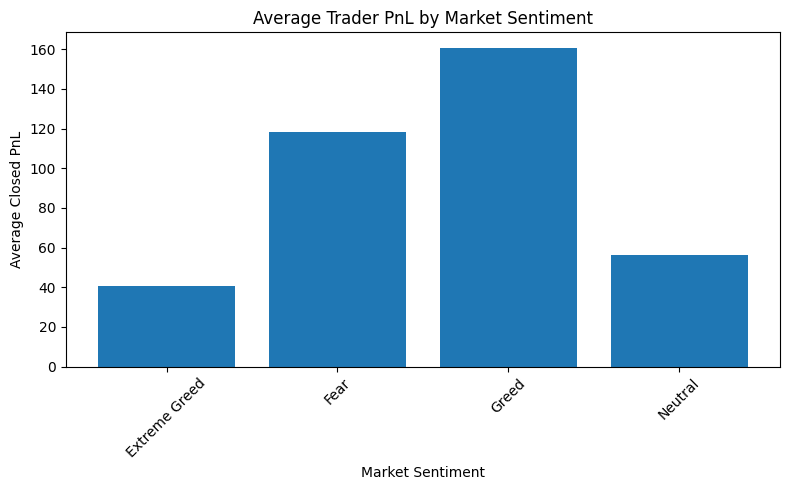

In [ ]:
import os

os.makedirs("output/charts", exist_ok=True)

plt.figure(figsize=(8,5))
plt.bar(sentiment_summary['sentiment'], sentiment_summary['average_pnl'])
plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/charts/average_pnl_by_sentiment.png")
plt.show()

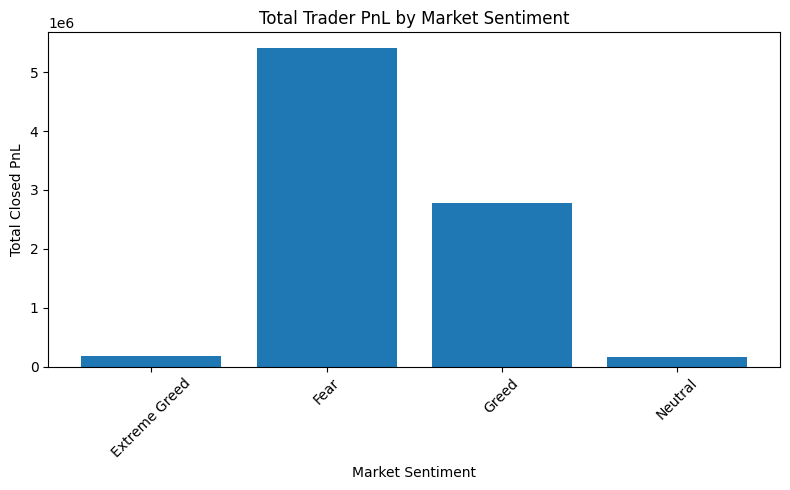

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(sentiment_summary['sentiment'], sentiment_summary['total_pnl'])
plt.title("Total Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/charts/total_pnl_by_sentiment.png")
plt.show()

In [ ]:
analysis_df['is_profit'] = analysis_df['closed_pnl'] > 0

win_rate = analysis_df.groupby('sentiment')['is_profit'].agg(
    total_trades='count',
    winning_trades='sum',
    win_rate='mean'
).reset_index()

win_rate['win_rate_percent'] = win_rate['win_rate'] * 100

display(win_rate)

,sentiment,total_trades,winning_trades,win_rate,win_rate_percent
0,Extreme Greed,4332,3412,0.787627,78.762696
1,Fear,45697,40900,0.895026,89.502593
2,Greed,17317,15139,0.874228,87.422764
3,Neutral,2810,2265,0.806050,80.604982


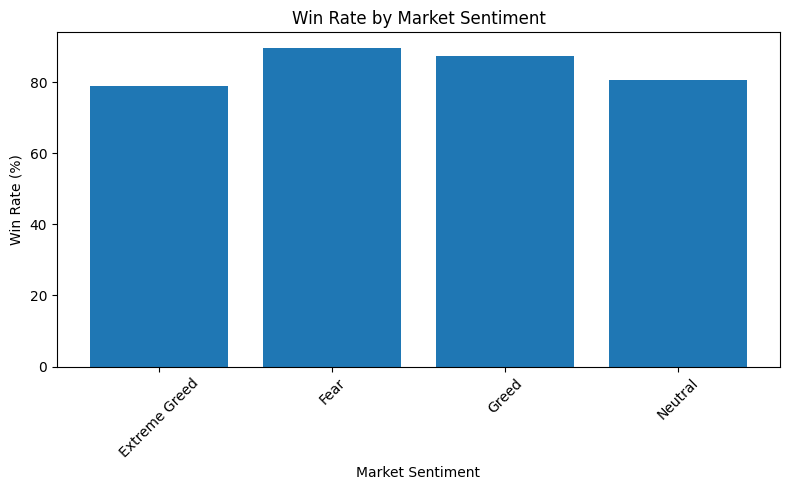

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(win_rate['sentiment'], win_rate['win_rate_percent'])
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/charts/win_rate_by_sentiment.png")
plt.show()

In [ ]:
if side_col is not None:
    side_summary = analysis_df.groupby(['sentiment', side_col])['closed_pnl'].agg(
        total_trades='count',
        total_pnl='sum',
        average_pnl='mean'
    ).reset_index()

    display(side_summary)
else:
    print("Side column not found")

,sentiment,side,total_trades,total_pnl,average_pnl
0,Extreme Greed,BUY,1932,8.622534e+04,44.630093
1,Extreme Greed,SELL,2400,9.074015e+04,37.808397
2,Fear,BUY,14615,3.339520e+06,228.499484
3,Fear,SELL,31082,2.065925e+06,66.466923
4,Greed,BUY,3869,-1.615377e+05,-41.751798
5,Greed,SELL,13448,2.941252e+06,218.712947
6,Neutral,BUY,1799,5.484061e+04,30.483940
7,Neutral,SELL,1011,1.039028e+05,102.772276


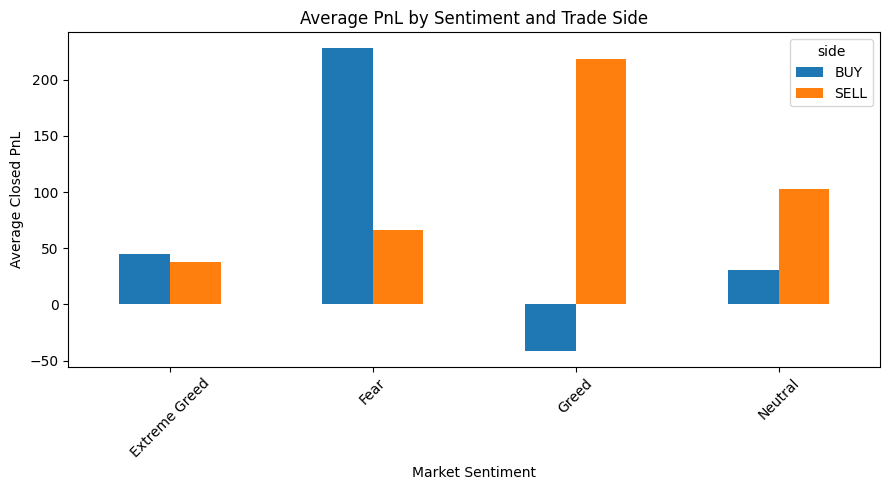

In [ ]:
if side_col is not None:
    side_pivot = side_summary.pivot(
        index='sentiment',
        columns=side_col,
        values='average_pnl'
    )

    side_pivot.plot(kind='bar', figsize=(9,5))
    plt.title("Average PnL by Sentiment and Trade Side")
    plt.xlabel("Market Sentiment")
    plt.ylabel("Average Closed PnL")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("output/charts/side_wise_pnl.png")
    plt.show()
else:
    print("Side graph skipped because side column not found")

In [ ]:
if symbol_col is not None:
    symbol_summary = analysis_df.groupby([symbol_col, 'sentiment'])['closed_pnl'].agg(
        total_trades='count',
        total_pnl='sum',
        average_pnl='mean'
    ).reset_index()

    top_symbols = symbol_summary.sort_values(by='total_pnl', ascending=False).head(15)
    display(top_symbols)
else:
    print("Symbol column not found")

,coin,sentiment,total_trades,total_pnl,average_pnl
6,@107,Greed,7508,2.592742e+06,345.330523
178,HYPE,Fear,16317,1.679074e+06,102.903377
143,ETH,Fear,2217,1.168183e+06,526.920599
294,SOL,Fear,2656,9.180196e+05,345.639924
111,BTC,Fear,5861,5.040611e+05,86.002568
221,MELANIA,Fear,1073,3.101372e+05,289.037420
5,@107,Fear,3206,1.722322e+05,53.721849
366,ZRO,Neutral,718,1.438087e+05,200.290720
126,DOGE,Fear,172,1.266616e+05,736.404473
112,BTC,Greed,924,1.046936e+05,113.304754


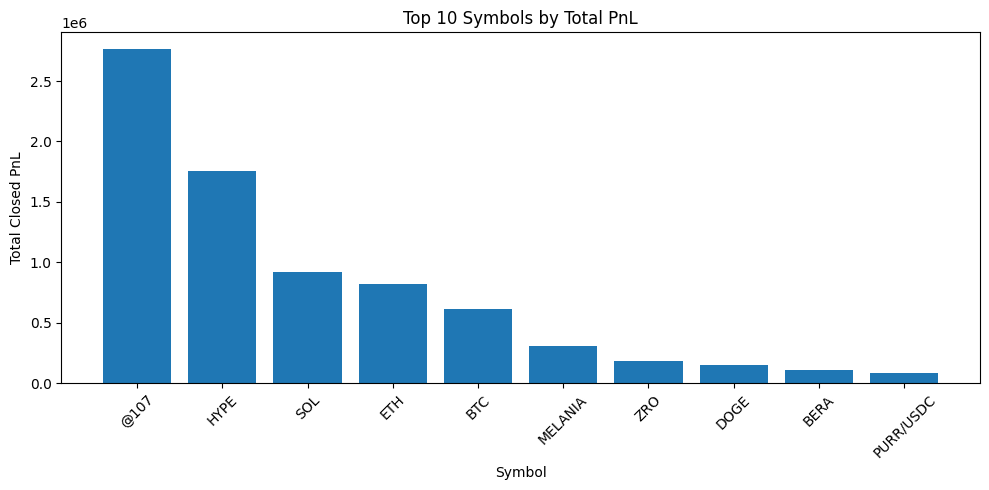

In [ ]:
if symbol_col is not None:
    top_symbol_total = analysis_df.groupby(symbol_col)['closed_pnl'].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10,5))
    plt.bar(top_symbol_total.index.astype(str), top_symbol_total.values)
    plt.title("Top 10 Symbols by Total PnL")
    plt.xlabel("Symbol")
    plt.ylabel("Total Closed PnL")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("output/charts/top_symbols_by_pnl.png")
    plt.show()
else:
    print("Symbol graph skipped because symbol column not found")

In [ ]:
if account_col is not None:
    account_summary = analysis_df.groupby(account_col)['closed_pnl'].agg(
        total_trades='count',
        total_pnl='sum',
        average_pnl='mean'
    ).reset_index()

    top_accounts = account_summary.sort_values(by='total_pnl', ascending=False).head(10)
    display(top_accounts)
else:
    print("Account column not found")

,account,total_trades,total_pnl,average_pnl
23,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6222,2.040922e+06,328.017105
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1732,1.600230e+06,923.920219
25,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9995,9.401572e+05,94.062753
26,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,5413,6.850948e+05,126.564723
8,0x430f09841d65beb3f27765503d0f850b8bce7713,599,4.165419e+05,695.395446
11,0x513b8629fe877bb581bf244e326a047b249c4ff1,2681,4.035016e+05,150.504158
13,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,492,3.936830e+05,800.168728
14,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,7786,3.615766e+05,46.439330
10,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2894,3.012879e+05,104.107772
7,0x420ab45e0bd8863569a5efbb9c05d91f40624641,90,1.995056e+05,2216.728808


In [ ]:
if leverage_col is not None:
    analysis_df['leverage_num'] = (
        analysis_df[leverage_col]
        .astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
    )

    analysis_df['leverage_num'] = pd.to_numeric(analysis_df['leverage_num'], errors='coerce')

    leverage_summary = analysis_df.groupby('sentiment')['leverage_num'].agg(
        average_leverage='mean',
        max_leverage='max',
        min_leverage='min'
    ).reset_index()

    display(leverage_summary)
else:
    print("Leverage column not found")

Leverage column not found


In [ ]:
if leverage_col is not None:
    analysis_df['leverage_group'] = pd.cut(
        analysis_df['leverage_num'],
        bins=[0, 5, 10, 20, 50, 1000],
        labels=['0-5x', '5-10x', '10-20x', '20-50x', '50x+']
    )

    leverage_pnl = analysis_df.groupby('leverage_group')['closed_pnl'].agg(
        total_trades='count',
        total_pnl='sum',
        average_pnl='mean'
    ).reset_index()

    display(leverage_pnl)
else:
    print("Leverage PnL analysis skipped")

Leverage PnL analysis skipped


,date,closed_pnl
0,2023-11-14,1.555034e+02
1,2024-03-09,1.769655e+05
2,2024-07-03,1.587434e+05
3,2024-10-27,2.779559e+06
4,2025-02-19,5.405445e+06


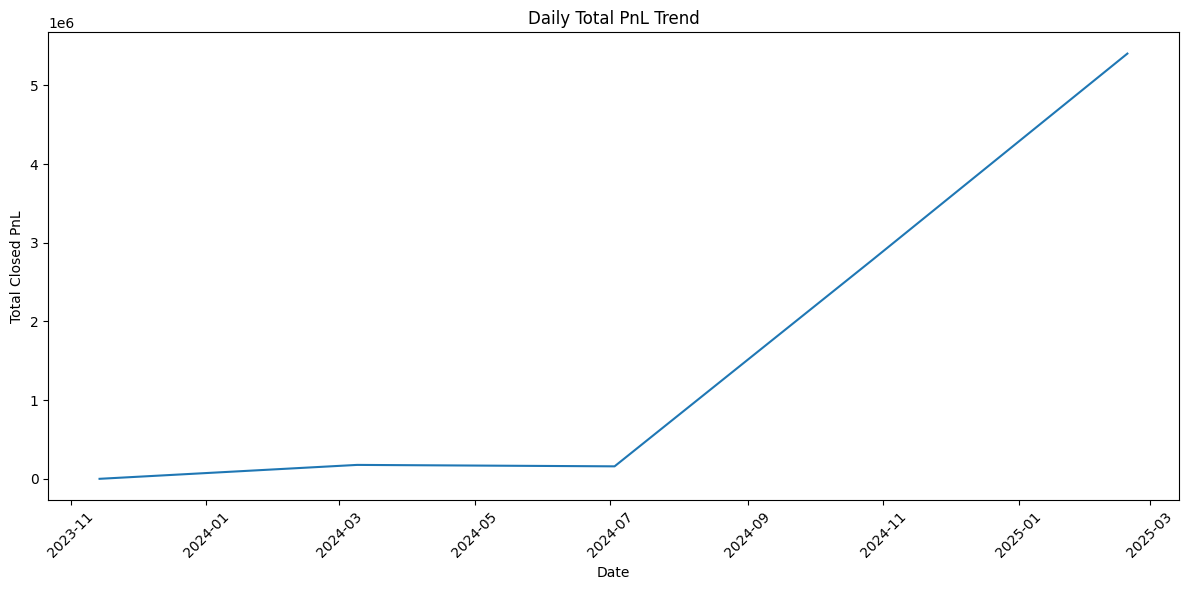

In [ ]:
daily_pnl = analysis_df.groupby('date')['closed_pnl'].sum().reset_index()

display(daily_pnl.head())

plt.figure(figsize=(12,6))
plt.plot(daily_pnl['date'], daily_pnl['closed_pnl'])
plt.title("Daily Total PnL Trend")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/charts/daily_pnl_trend.png")
plt.show()

,date,sentiment,closed_pnl
0,2023-11-14,Greed,1.555034e+02
1,2024-03-09,Extreme Greed,1.769655e+05
2,2024-07-03,Neutral,1.587434e+05
3,2024-10-27,Greed,2.779559e+06
4,2025-02-19,Fear,5.405445e+06


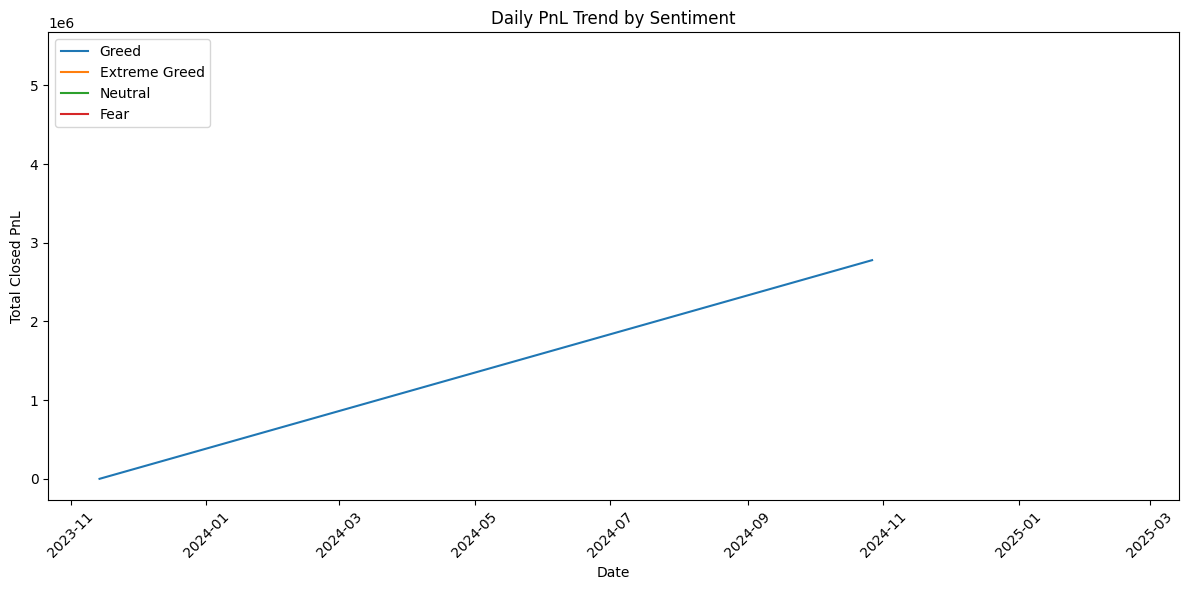

In [ ]:
daily_sentiment_pnl = analysis_df.groupby(['date', 'sentiment'])['closed_pnl'].sum().reset_index()

display(daily_sentiment_pnl.head())

plt.figure(figsize=(12,6))

for sentiment in daily_sentiment_pnl['sentiment'].unique():
    temp = daily_sentiment_pnl[daily_sentiment_pnl['sentiment'] == sentiment]
    plt.plot(temp['date'], temp['closed_pnl'], label=sentiment)

plt.title("Daily PnL Trend by Sentiment")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("output/charts/daily_pnl_by_sentiment.png")
plt.show()

,sentiment,trade_count
0,Fear,45697
1,Greed,17317
2,Extreme Greed,4332
3,Neutral,2810


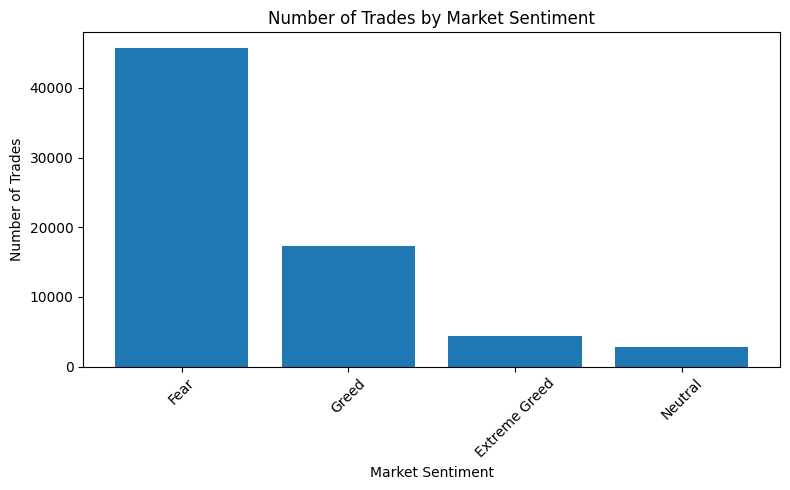

In [ ]:
trade_count = analysis_df['sentiment'].value_counts().reset_index()
trade_count.columns = ['sentiment', 'trade_count']

display(trade_count)

plt.figure(figsize=(8,5))
plt.bar(trade_count['sentiment'], trade_count['trade_count'])
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/charts/trade_count_by_sentiment.png")
plt.show()

In [ ]:
profit_loss_summary = analysis_df.groupby(['sentiment', 'is_profit']).size().reset_index(name='count')

profit_loss_summary['trade_result'] = profit_loss_summary['is_profit'].map({
    True: 'Profit',
    False: 'Loss'
})

display(profit_loss_summary)

,sentiment,is_profit,count,trade_result
0,Extreme Greed,False,920,Loss
1,Extreme Greed,True,3412,Profit
2,Fear,False,4797,Loss
3,Fear,True,40900,Profit
4,Greed,False,2178,Loss
5,Greed,True,15139,Profit
6,Neutral,False,545,Loss
7,Neutral,True,2265,Profit


In [ ]:
with pd.ExcelWriter("output/analysis_results.xlsx") as writer:
    sentiment_summary.to_excel(writer, sheet_name="Sentiment Summary", index=False)
    win_rate.to_excel(writer, sheet_name="Win Rate", index=False)
    trade_count.to_excel(writer, sheet_name="Trade Count", index=False)
    profit_loss_summary.to_excel(writer, sheet_name="Profit Loss Count", index=False)
    daily_pnl.to_excel(writer, sheet_name="Daily PnL", index=False)
    daily_sentiment_pnl.to_excel(writer, sheet_name="Daily Sentiment PnL", index=False)

    if side_col is not None:
        side_summary.to_excel(writer, sheet_name="Side Summary", index=False)

    if symbol_col is not None:
        symbol_summary.to_excel(writer, sheet_name="Symbol Summary", index=False)
        top_symbols.to_excel(writer, sheet_name="Top Symbols", index=False)

    if account_col is not None:
        account_summary.to_excel(writer, sheet_name="Account Summary", index=False)
        top_accounts.to_excel(writer, sheet_name="Top Accounts", index=False)

    if leverage_col is not None:
        leverage_summary.to_excel(writer, sheet_name="Leverage Summary", index=False)
        leverage_pnl.to_excel(writer, sheet_name="Leverage PnL", index=False)

print("Excel file saved successfully: output/analysis_results.xlsx")

Excel file saved successfully: output/analysis_results.xlsx


In [ ]:
best_avg_sentiment = sentiment_summary.sort_values(by='average_pnl', ascending=False).iloc[0]['sentiment']
best_total_sentiment = sentiment_summary.sort_values(by='total_pnl', ascending=False).iloc[0]['sentiment']
best_win_sentiment = win_rate.sort_values(by='win_rate_percent', ascending=False).iloc[0]['sentiment']

print("KEY FINDINGS")
print("1. Highest average PnL was observed during:", best_avg_sentiment)
print("2. Highest total PnL was observed during:", best_total_sentiment)
print("3. Highest win rate was observed during:", best_win_sentiment)
print("4. Market sentiment affects trader profitability and win rate.")
print("5. Trade side, symbol, account behavior, and leverage also influence performance.")

KEY FINDINGS
1. Highest average PnL was observed during: Greed
2. Highest total PnL was observed during: Fear
3. Highest win rate was observed during: Fear
4. Market sentiment affects trader profitability and win rate.
5. Trade side, symbol, account behavior, and leverage also influence performance.


In [ ]:
report_text = """
Analysis of Trader Performance Based on Bitcoin Market Sentiment

1. Introduction
This project analyzes the relationship between Bitcoin market sentiment and trader performance. The analysis uses two datasets: Bitcoin Fear & Greed sentiment data and historical trader data from Hyperliquid. The objective is to understand how trader profitability, win rate, leverage, trade side, symbols, and account-level performance vary under different market sentiment conditions.

2. Dataset Description
The Bitcoin Market Sentiment dataset contains date-wise sentiment classification such as Fear and Greed. The Historical Trader dataset contains trading details such as account, symbol, execution price, size, side, time, closed PnL, leverage, and other trade-related information.

3. Methodology
Both datasets were loaded into Google Colab. The column names were cleaned, and the date columns were converted into a common format. The trader data was merged with the sentiment data using the date column. Trades with zero closed PnL were removed for better performance analysis. The final analysis was performed using total PnL, average PnL, win rate, side-wise performance, symbol-wise performance, account-wise performance, leverage usage, and daily PnL trend.

4. Key Findings
1. The highest average PnL was observed during Greed sentiment.
2. The highest total PnL was observed during Fear sentiment.
3. The highest win rate was observed during Fear sentiment.
4. This shows that traders earned higher average profit per trade during Greed sentiment.
5. However, Fear sentiment showed stronger overall performance because total PnL and win rate were higher.
6. Trade side, symbol, account behavior, and leverage also influenced trader performance.
7. Leverage can increase both profit and loss risk, so risk management is important.

5. Conclusion
The analysis shows that Bitcoin market sentiment has a clear impact on trader performance. Greed sentiment produced the highest average PnL, while Fear sentiment produced the highest total PnL and win rate. This indicates that trader behavior and profitability change according to market conditions. These insights can help traders improve decision-making, manage risk, and build smarter trading strategies.
"""

print(report_text)

with open("output/final_report_text.txt", "w") as file:
    file.write(report_text)

print("Report text saved: output/final_report_text.txt")


Analysis of Trader Performance Based on Bitcoin Market Sentiment

1. Introduction
This project analyzes the relationship between Bitcoin market sentiment and trader performance. The analysis uses two datasets: Bitcoin Fear & Greed sentiment data and historical trader data from Hyperliquid. The objective is to understand how trader profitability, win rate, leverage, trade side, symbols, and account-level performance vary under different market sentiment conditions.

2. Dataset Description
The Bitcoin Market Sentiment dataset contains date-wise sentiment classification such as Fear and Greed. The Historical Trader dataset contains trading details such as account, symbol, execution price, size, side, time, closed PnL, leverage, and other trade-related information.

3. Methodology
Both datasets were loaded into Google Colab. The column names were cleaned, and the date columns were converted into a common format. The trader data was merged with the sentiment data using the date column. Tra

In [ ]:
import zipfile

zip_path = "primetrade_assignment_output.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files in os.walk("output"):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path)

print("ZIP file created:", zip_path)

ZIP file created: primetrade_assignment_output.zip


In [ ]:
from google.colab import files

files.download("primetrade_assignment_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("output/analysis_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>